<a href="https://colab.research.google.com/github/csandoval5/Mineria-de-Datos/blob/main/PracticoExperimental.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


Iniciamos cargando las herramientas de manipulación de datos, visualización y aprendizaje automático.

In [1]:
# Importación de librerías para manejo de datos y visualización
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Herramientas de preprocesamiento y modelado
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay

 Preparación de los Datos aqui cargamos los datos de nuestro dataset

In [2]:
# Carga de archivos CSV
orders = pd.read_csv('olist_orders_dataset.csv')
items = pd.read_csv('olist_order_items_dataset.csv')
reviews = pd.read_csv('olist_order_reviews_dataset.csv')

# Integración de tablas (Merge) para crear el dataset maestro
df = pd.merge(orders, items, on='order_id')
df = pd.merge(df, reviews, on='order_id')

print(f"Total de registros cargados: {len(df)}")

Total de registros cargados: 112372


insertamos una pequeña grafica para poder vizualizar los datos del dataset

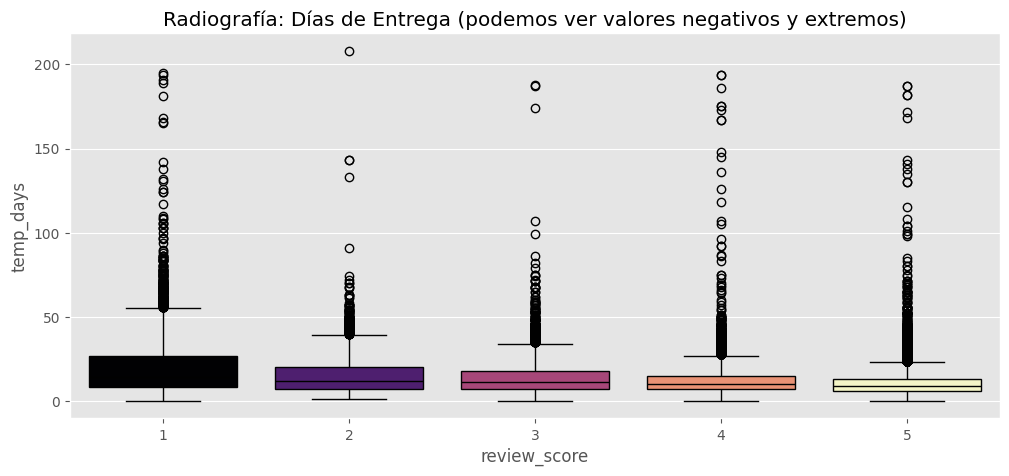

Registros iniciales con posibles errores: 112372


In [5]:
# Cálculo temporal solo para visualización
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])
df['order_delivered_customer_date'] = pd.to_datetime(df['order_delivered_customer_date'])
df['temp_days'] = (df['order_delivered_customer_date'] - df['order_purchase_timestamp']).dt.days

# Visualización de los datos
plt.figure(figsize=(12, 5))
sns.boxplot(x='review_score', y='temp_days', data=df, hue='review_score', palette='magma', legend=False)
plt.title('Radiografía: Días de Entrega (podemos ver valores negativos y extremos)')
plt.show()

print(f"Registros iniciales con posibles errores: {len(df)}")

Preparación de Datos
Transformamos los datos brutos en variables útiles y eliminamos errores lógicos (anomalías).

In [10]:
# 1. Limpieza: Eliminación de valores nulos
df = df.dropna(subset=['review_score', 'order_delivered_customer_date']).copy()

# 2. Transformación: Cálculo de días de entrega
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])
df['order_delivered_customer_date'] = pd.to_datetime(df['order_delivered_customer_date'])
df['delivery_days'] = (df['order_delivered_customer_date'] - df['order_purchase_timestamp']).dt.days

# 3. Tratamiento de anomalías: Filtramos y volvemos a asegurar la copia
df = df[df['delivery_days'] >= 0].copy()

# 4. Binarización del Target
df['target_satisfaccion'] = df['review_score'].apply(lambda x: 1 if x >= 4 else 0)

print("Datos procesados correctamente.")

Datos procesados correctamente.


Modelado
Aqui aplicamos la división 80% para entrenamiento y 20% para prueba.

In [11]:
# Selección de variables predictoras (Features) y objetivo (Target)
X = df[['price', 'freight_value', 'delivery_days']]
y = df['target_satisfaccion']

# División técnica 80-20
# test_size=0.20 significa que el 20% es para prueba y el 80% para entrenamiento
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# Normalización de datos (StandardScaler)
# Esto es vital para que la Regresión Logística y la Red Neuronal no den error de convergencia
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("División 80/20 y escalamiento completados con éxito.")

División 80/20 y escalamiento completados con éxito.


Entrenamiento de 3 técnicas apropiadas
Implementamos los algoritmos requeridos por la guía del practico experimental para comparar su rendimiento.

In [12]:
# Definición de modelos con parámetros optimizados
modelos = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Regresión Logística": LogisticRegression(max_iter=2000),
    "Red Neuronal": MLPClassifier(hidden_layer_sizes=(10, 10), max_iter=1000, random_state=42)
}

# Entrenamiento en bucle
for nombre, modelo in modelos.items():
    modelo.fit(X_train_scaled, y_train)
    print(f"Modelo {nombre} entrenado correctamente.")

Modelo Random Forest entrenado correctamente.
Modelo Regresión Logística entrenado correctamente.
Modelo Red Neuronal entrenado correctamente.


Evaluamos
Generamos las métricas y la Matriz de Confusión para documentar los hallazgos en el reporte técnico.


--- REPORTE TÉCNICO: Random Forest ---
Exactitud (Accuracy): 0.7959


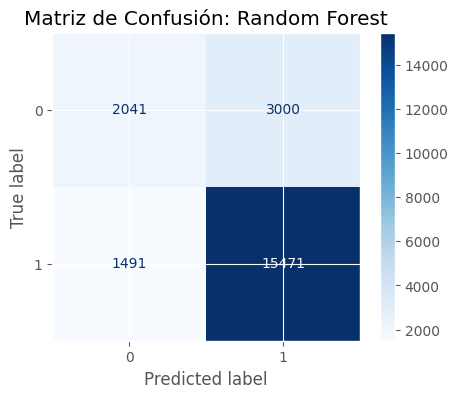


--- REPORTE TÉCNICO: Regresión Logística ---
Exactitud (Accuracy): 0.7909


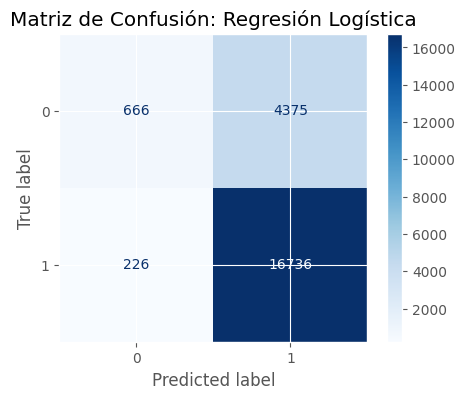


--- REPORTE TÉCNICO: Red Neuronal ---
Exactitud (Accuracy): 0.7927


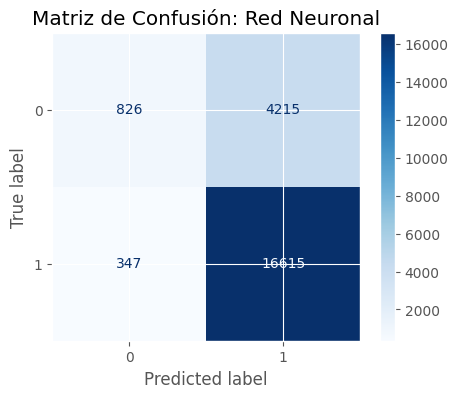

In [13]:
for nombre, modelo in modelos.items():
    y_pred = modelo.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)

    print(f"\n--- REPORTE TÉCNICO: {nombre} ---")
    print(f"Exactitud (Accuracy): {acc:.4f}")

    # Visualización
    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax, cmap='Blues')
    plt.title(f'Matriz de Confusión: {nombre}')
    plt.show()